# Classification Algorithms In Practice
## Unit 3, Day 5 - Interactive Walkthrough

**Instructor:** Abishek Ganesh

Welcome! In this notebook, we'll explore classification algorithms and see how they differ from regression.

**What we'll cover:**
1. Classification vs Regression - Understanding the difference
2. The Titanic Dataset - A classic binary classification problem
3. Logistic Regression - Our workhorse classifier
4. Evaluation Metrics - Accuracy, Confusion Matrix, Precision, Recall, F1
5. Decision Trees for Classification - A different approach
6. Comparing Models

---
## Setup: Import Libraries

Run this cell first to load all the tools we'll need.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Machine Learning - Data Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
# Part 1: Classification vs Regression
## When Do We Use Which?

Before we dive in, let's clearly understand the difference:

| Aspect | Regression | Classification |
|--------|------------|----------------|
| **Output** | Continuous number | Category/Class |
| **Question** | "How much?" | "Which one?" |
| **Example** | Predict house price: \$285,000 | Predict survival: Yes or No |
| **Metrics** | R², RMSE, MAE | Accuracy, Precision, Recall, F1 |

> **Analogy:** Think of it like this:
> - **Regression** is like a thermometer - it gives you an exact number (72.5°F)
> - **Classification** is like a light switch - it picks one state (ON or OFF)

In [12]:
# Let's think about these problems:
problems = [
    ("Predicting tomorrow's temperature", "Regression", "Continuous number"),
    ("Detecting spam emails", "Classification", "Spam or Not Spam"),
    ("Predicting customer churn", "Classification", "Will Leave or Won't Leave"),
    ("Estimating delivery time", "Regression", "Continuous number (minutes)"),
    ("Diagnosing a disease", "Classification", "Positive or Negative"),
    ("Predicting stock prices", "Regression", "Continuous number ($)"),
    ("Titanic survival prediction", "Classification", "Survived or Died"),
]

print("Examples of Regression vs Classification Problems:")
print("="*70)
print(f"{'Problem':<35} {'Type':<18} {'Output'}")
print("-"*70)
for problem, ptype, output in problems:
    print(f"{problem:<35} {ptype:<18} {output}")
print("="*70)
print("\nKey insight: If you're predicting a CATEGORY, it's classification!")
print("If you're predicting a NUMBER on a continuous scale, it's regression!")

Examples of Regression vs Classification Problems:
Problem                             Type               Output
----------------------------------------------------------------------
Predicting tomorrow's temperature   Regression         Continuous number
Detecting spam emails               Classification     Spam or Not Spam
Predicting customer churn           Classification     Will Leave or Won't Leave
Estimating delivery time            Regression         Continuous number (minutes)
Diagnosing a disease                Classification     Positive or Negative
Predicting stock prices             Regression         Continuous number ($)
Titanic survival prediction         Classification     Survived or Died

Key insight: If you're predicting a CATEGORY, it's classification!
If you're predicting a NUMBER on a continuous scale, it's regression!


---
# Part 2: The Titanic Dataset
## A Classic Binary Classification Problem

The Titanic dataset is one of the most famous datasets in machine learning. The goal is to predict whether a passenger **survived** or **died** based on features like:

- **Pclass**: Ticket class (1st, 2nd, 3rd)
- **Sex**: Male or Female
- **Age**: Age in years
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Fare**: Ticket price

**Target (what we predict):**
- **Survived**: 0 = Died, 1 = Survived

This is **binary classification** - exactly two possible outcomes!

In [13]:
# Load the Titanic dataset from a URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSurvival distribution:")
print(df['Survived'].value_counts())
print(f"\nSurvival rate: {df['Survived'].mean()*100:.1f}%")

Dataset shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Survival distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.4%


In [14]:
# Look at the first few rows
print("First 10 passengers:")
df[['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Fare']].head(10)

First 10 passengers:


,Survived,Pclass,Name,Sex,Age,Fare
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500
5,0,3,"Moran, Mr. James",male,NaN,8.4583
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,51.8625
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,21.0750
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,11.1333
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,30.0708


In [15]:
# Quick statistics
df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Data Preparation

Before we can train a model, we need to:
1. Handle missing values
2. Convert categorical variables to numbers
3. Select relevant features

In [16]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nAge has {df['Age'].isnull().sum()} missing values - we'll fill with median")

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age has 177 missing values - we'll fill with median


In [17]:
# Prepare the data
# Create a copy for modeling
df_model = df.copy()

# Fill missing Age with median
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())

# Convert Sex to numeric (0 = female, 1 = male)
df_model['Sex_numeric'] = (df_model['Sex'] == 'male').astype(int)

# Select features for our model
features = ['Pclass', 'Sex_numeric', 'Age', 'SibSp', 'Parch', 'Fare']
X = df_model[features]
y = df_model['Survived']

print("Features we'll use:")
print(X.head())
print(f"\nTarget (Survived):")
print(y.head())

Features we'll use:
   Pclass  Sex_numeric   Age  SibSp  Parch     Fare
0       3            1  22.0      1      0   7.2500
1       1            0  38.0      1      0  71.2833
2       3            0  26.0      0      0   7.9250
3       1            0  35.0      1      0  53.1000
4       3            1  35.0      0      0   8.0500

Target (Survived):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


### Visualizing the Data

Let's see how different features relate to survival!

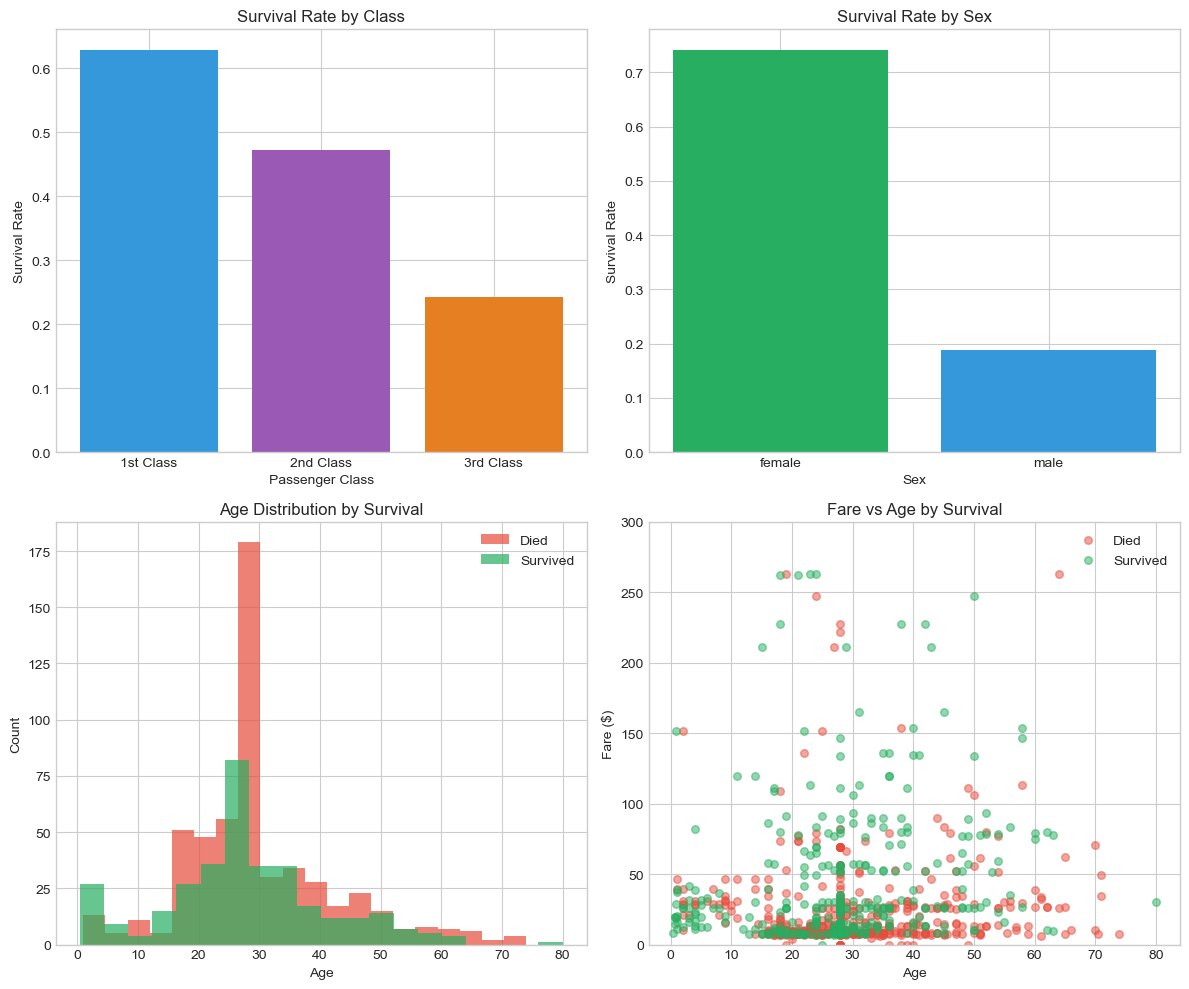

Observations:
- 1st class passengers had much higher survival rates
- Women survived at much higher rates than men ('Women and children first')
- Higher fares (often 1st class) correlate with survival


In [18]:
# Visualize survival by different features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Colors: Green for survived, Red for died
colors = {0: '#E74C3C', 1: '#27AE60'}  # Red = died, Green = survived

# Plot 1: Survival by Class
survival_by_class = df_model.groupby('Pclass')['Survived'].mean()
axes[0, 0].bar(survival_by_class.index, survival_by_class.values, color=['#3498DB', '#9B59B6', '#E67E22'])
axes[0, 0].set_xlabel('Passenger Class')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_title('Survival Rate by Class')
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

# Plot 2: Survival by Sex
survival_by_sex = df_model.groupby('Sex')['Survived'].mean()
axes[0, 1].bar(survival_by_sex.index, survival_by_sex.values, color=['#27AE60', '#3498DB'])
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_title('Survival Rate by Sex')

# Plot 3: Age distribution by survival
survived = df_model[df_model['Survived'] == 1]['Age']
died = df_model[df_model['Survived'] == 0]['Age']
axes[1, 0].hist(died, bins=20, alpha=0.7, label='Died', color='#E74C3C')
axes[1, 0].hist(survived, bins=20, alpha=0.7, label='Survived', color='#27AE60')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Age Distribution by Survival')
axes[1, 0].legend()

# Plot 4: Fare vs Age colored by survival
for survival_status, color in colors.items():
    subset = df_model[df_model['Survived'] == survival_status]
    label = 'Survived' if survival_status == 1 else 'Died'
    axes[1, 1].scatter(subset['Age'], subset['Fare'], c=color, label=label, alpha=0.5, s=30)
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Fare ($)')
axes[1, 1].set_title('Fare vs Age by Survival')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 300)  # Limit y-axis for better visualization

plt.tight_layout()
plt.show()

print("Observations:")
print("- 1st class passengers had much higher survival rates")
print("- Women survived at much higher rates than men ('Women and children first')")
print("- Higher fares (often 1st class) correlate with survival")

### Prepare the Data for Machine Learning

In [19]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nClass distribution in training set:")
print(f"  Died: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Survived: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nClass distribution in test set:")
print(f"  Died: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Survived: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

print("\nNote: We used stratify=y to ensure equal class proportions in both sets!")

Training samples: 712
Testing samples: 179

Class distribution in training set:
  Died: 439 (61.7%)
  Survived: 273 (38.3%)

Class distribution in test set:
  Died: 110 (61.5%)
  Survived: 69 (38.5%)

Note: We used stratify=y to ensure equal class proportions in both sets!


---
# Part 3: Logistic Regression
## Don't Let the Name Fool You!

Despite having "regression" in its name, **Logistic Regression is a classification algorithm!**

> **Why the confusing name?** Logistic Regression uses a regression-like formula internally, but then applies a special function (the sigmoid/logistic function) to convert the output into probabilities, which are then used to make class predictions.

> **Analogy:** Think of Logistic Regression like a confident opinion-giver:
> - It looks at the evidence (features)
> - Calculates how strongly the evidence points to each class
> - Outputs a probability: "I'm 85% sure this passenger survived"
> - Then makes a decision: probability > 0.5 → Survived, otherwise → Died

### How Logistic Regression Works (Simplified)

**Step 1: Calculate a weighted sum (like linear regression)**
```
z = w₁×Pclass + w₂×Sex + w₃×Age + w₄×SibSp + w₅×Parch + w₆×Fare + b
```

**Step 2: Apply the sigmoid function to get a probability**
```
probability = 1 / (1 + e^(-z))
```

The sigmoid function "squishes" any number into a probability between 0 and 1.

**Step 3: Make a prediction**
- If probability > 0.5 → Predict "Survived" (class 1)
- If probability ≤ 0.5 → Predict "Died" (class 0)

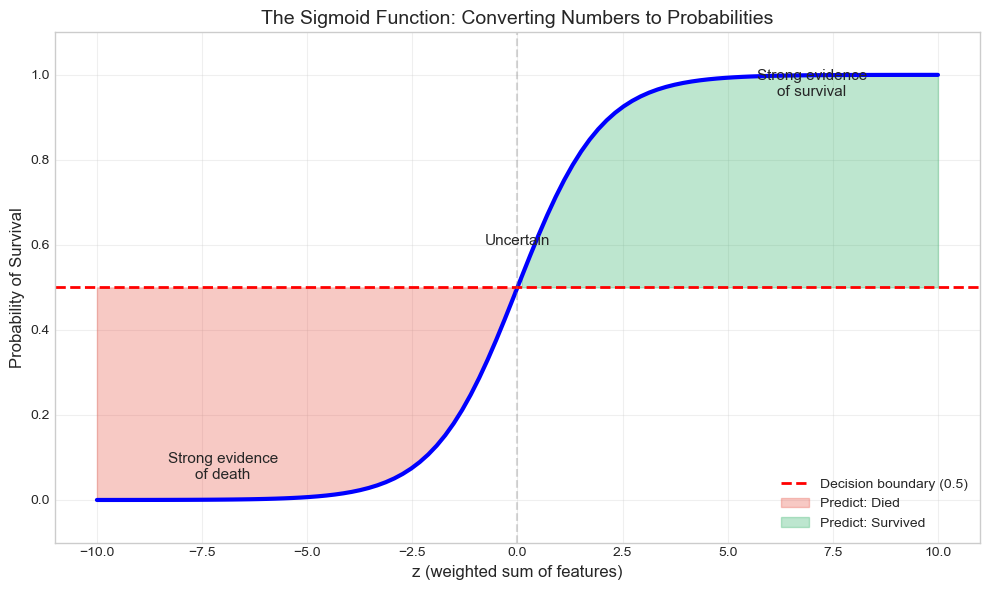

Key insight: The sigmoid function turns ANY number into a probability between 0 and 1!
  - Very negative z → close to 0 (predict death)
  - Very positive z → close to 1 (predict survival)
  - z near 0 → close to 0.5 (uncertain)


In [23]:
# Let's visualize the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_values, 'b-', linewidth=3)
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Decision boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# Add shaded regions
plt.fill_between(z_values, sigmoid_values, 0.5, where=(sigmoid_values < 0.5), 
                 color='#E74C3C', alpha=0.3, label='Predict: Died')
plt.fill_between(z_values, sigmoid_values, 0.5, where=(sigmoid_values >= 0.5), 
                 color='#27AE60', alpha=0.3, label='Predict: Survived')

plt.xlabel('z (weighted sum of features)', fontsize=12)
plt.ylabel('Probability of Survival', fontsize=12)
plt.title('The Sigmoid Function: Converting Numbers to Probabilities', fontsize=14)
plt.ylim(-0.1, 1.1)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Add annotations
plt.annotate('Strong evidence\nof death', xy=(-7, 0.05), fontsize=11, ha='center')
plt.annotate('Uncertain', xy=(0, 0.6), fontsize=11, ha='center')
plt.annotate('Strong evidence\nof survival', xy=(7, 0.95), fontsize=11, ha='center')

plt.tight_layout()
plt.show()

print("Key insight: The sigmoid function turns ANY number into a probability between 0 and 1!")
print("  - Very negative z → close to 0 (predict death)")
print("  - Very positive z → close to 1 (predict survival)")
print("  - z near 0 → close to 0.5 (uncertain)")

### Train Our Logistic Regression Model

> **Consulting Story:** In healthcare, logistic regression is incredibly popular because it's interpretable. When predicting hospital readmission risk, administrators want to know WHY a patient is high risk. Logistic regression coefficients tell us exactly that - "being male increases the odds of readmission by X%". That transparency builds trust with clinical staff.

In [24]:
# Scale the features first (important for logistic regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Why scale the data?")
print("- Logistic regression uses gradient descent to find the best weights")
print("- When features have very different scales, the algorithm struggles")
print("- Scaling puts all features on an equal footing")
print(f"\nBefore scaling - Fare range: {X_train['Fare'].min():.1f} to {X_train['Fare'].max():.1f}")
print(f"Before scaling - Age range: {X_train['Age'].min():.1f} to {X_train['Age'].max():.1f}")
print(f"After scaling - both features have mean~0 and std~1")

Why scale the data?
- Logistic regression uses gradient descent to find the best weights
- When features have very different scales, the algorithm struggles
- Scaling puts all features on an equal footing

Before scaling - Fare range: 0.0 to 512.3
Before scaling - Age range: 0.4 to 80.0
After scaling - both features have mean~0 and std~1


In [25]:
# Create and train the logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained!")
print(f"\nClasses: {log_reg.classes_} (0=Died, 1=Survived)")

Logistic Regression model trained!

Classes: [0 1] (0=Died, 1=Survived)


In [26]:
# Make predictions
y_pred = log_reg.predict(X_test_scaled)

# We can also get probability predictions!
y_pred_proba = log_reg.predict_proba(X_test_scaled)

print("Sample predictions (first 10 test passengers):")
print("="*70)
print(f"{'Actual':<12} {'Predicted':<12} {'P(Died)':<12} {'P(Survived)':<12}")
print("-"*70)

for i in range(10):
    actual = 'Survived' if y_test.iloc[i] == 1 else 'Died'
    predicted = 'Survived' if y_pred[i] == 1 else 'Died'
    prob_died = y_pred_proba[i][0] * 100
    prob_survived = y_pred_proba[i][1] * 100
    
    # Mark correct/incorrect
    mark = '✓' if y_test.iloc[i] == y_pred[i] else '✗'
    print(f"{actual:<12} {predicted:<12} {prob_died:<12.1f} {prob_survived:<12.1f} {mark}")

print("="*70)
print("\nNotice: The model outputs probabilities for EACH class!")
print("It then picks the class with the highest probability.")

Sample predictions (first 10 test passengers):
Actual       Predicted    P(Died)      P(Survived) 
----------------------------------------------------------------------
Died         Died         92.6         7.4          ✓
Died         Died         94.8         5.2          ✓
Survived     Died         87.7         12.3         ✗
Died         Died         96.1         3.9          ✓
Survived     Survived     43.3         56.7         ✓
Survived     Died         50.8         49.2         ✗
Survived     Survived     21.5         78.5         ✓
Died         Died         65.6         34.4         ✓
Died         Died         71.6         28.4         ✓
Died         Died         82.7         17.3         ✓

Notice: The model outputs probabilities for EACH class!
It then picks the class with the highest probability.


### Visualizing How Logistic Regression Makes Predictions

Let's see how the model assigns different survival probabilities to different types of passengers!

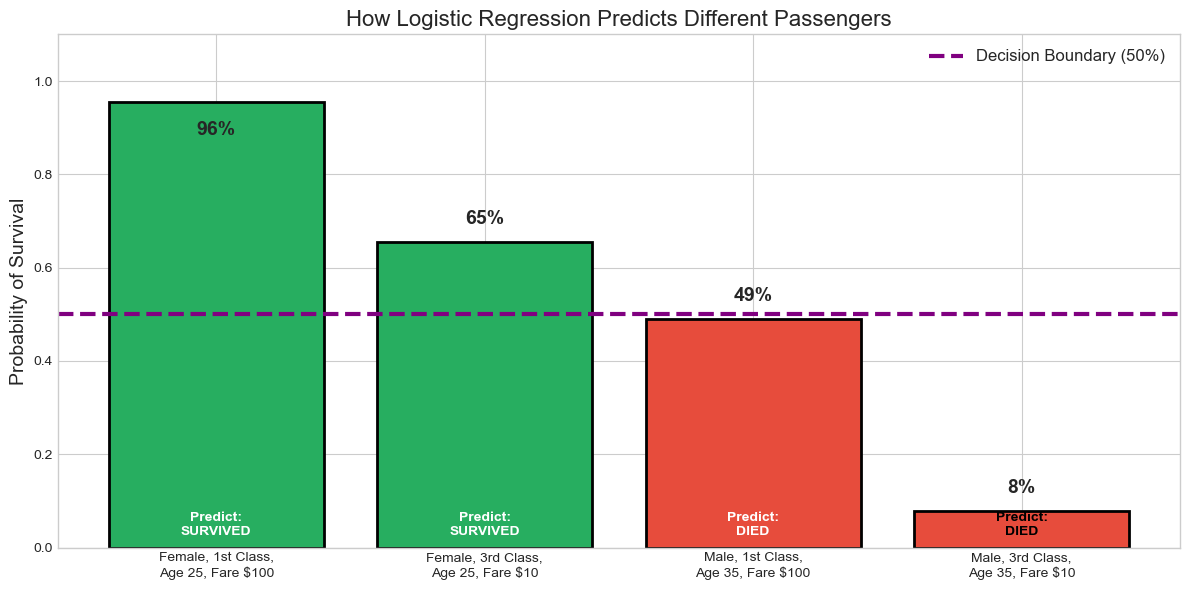

What this shows:
- GREEN bars: Model predicts SURVIVAL (probability > 50%)
- RED bars: Model predicts DEATH (probability < 50%)
- The PURPLE line is the decision boundary at 50%

Key insight: Being female dramatically increases survival probability!


In [27]:
# Let's create some passenger profiles and see what the model predicts
# Create different passenger scenarios
profiles = [
    {'name': 'Female, 1st Class,\nAge 25, Fare $100', 'Pclass': 1, 'Sex_numeric': 0, 'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 100},
    {'name': 'Female, 3rd Class,\nAge 25, Fare $10', 'Pclass': 3, 'Sex_numeric': 0, 'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 10},
    {'name': 'Male, 1st Class,\nAge 35, Fare $100', 'Pclass': 1, 'Sex_numeric': 1, 'Age': 35, 'SibSp': 0, 'Parch': 0, 'Fare': 100},
    {'name': 'Male, 3rd Class,\nAge 35, Fare $10', 'Pclass': 3, 'Sex_numeric': 1, 'Age': 35, 'SibSp': 0, 'Parch': 0, 'Fare': 10},
]

# Get predictions for each profile
names = []
probabilities = []

for profile in profiles:
    name = profile.pop('name')
    names.append(name)
    
    # Create a DataFrame with the profile
    profile_df = pd.DataFrame([profile])
    profile_scaled = scaler.transform(profile_df)
    
    # Get probability of survival
    prob = log_reg.predict_proba(profile_scaled)[0][1]
    probabilities.append(prob)

# Plot
plt.figure(figsize=(12, 6))

# Color bars based on whether they cross the 0.5 threshold
colors = ['#27AE60' if p > 0.5 else '#E74C3C' for p in probabilities]
bars = plt.bar(names, probabilities, color=colors, edgecolor='black', linewidth=2)

# Add decision boundary line
plt.axhline(y=0.5, color='purple', linestyle='--', linewidth=3, label='Decision Boundary (50%)')

# Add percentage labels on bars
for bar, prob in zip(bars, probabilities):
    height = bar.get_height()
    label_y = height + 0.03 if height < 0.9 else height - 0.08
    plt.text(bar.get_x() + bar.get_width()/2., label_y, f'{prob*100:.0f}%', 
             ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('Probability of Survival', fontsize=14)
plt.title('How Logistic Regression Predicts Different Passengers', fontsize=16)
plt.ylim(0, 1.1)
plt.legend(loc='upper right', fontsize=12)

# Add prediction labels
for i, (bar, prob) in enumerate(zip(bars, probabilities)):
    prediction = 'SURVIVED' if prob > 0.5 else 'DIED'
    plt.text(bar.get_x() + bar.get_width()/2., 0.02, f'Predict:\n{prediction}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             color='white' if prob > 0.3 else 'black')

plt.tight_layout()
plt.show()

print("What this shows:")
print("- GREEN bars: Model predicts SURVIVAL (probability > 50%)")
print("- RED bars: Model predicts DEATH (probability < 50%)")
print("- The PURPLE line is the decision boundary at 50%")
print("\nKey insight: Being female dramatically increases survival probability!")

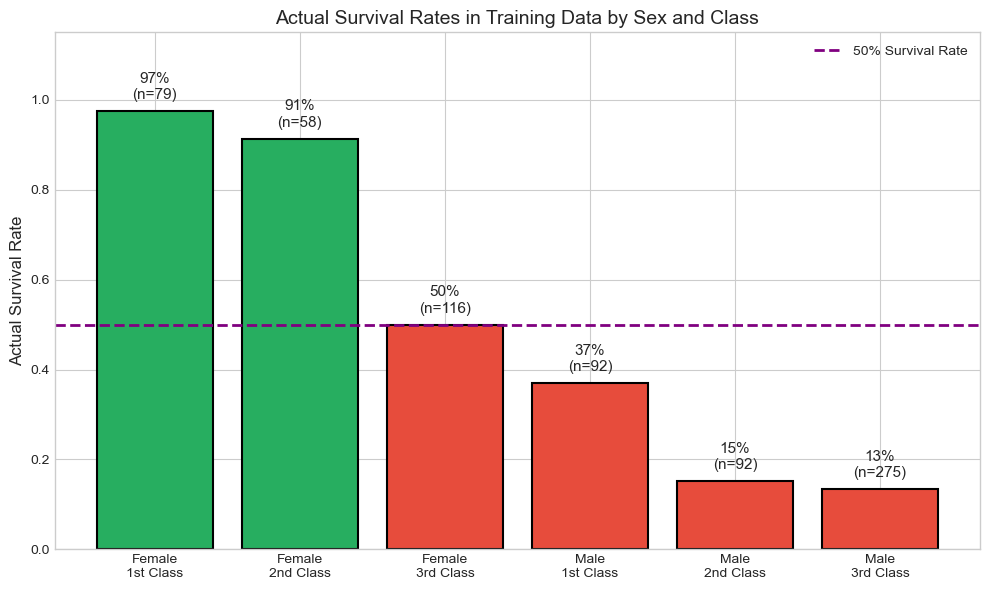

The model learned these patterns from the data!
- Women in 1st and 2nd class had very high survival rates
- Men in all classes had much lower survival rates
- 'Women and children first' was real!


In [28]:
# Let's also see the actual survival rates in our training data
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate actual survival rates for different groups
groups = {
    'Female\n1st Class': (X_train['Sex_numeric'] == 0) & (X_train['Pclass'] == 1),
    'Female\n2nd Class': (X_train['Sex_numeric'] == 0) & (X_train['Pclass'] == 2),
    'Female\n3rd Class': (X_train['Sex_numeric'] == 0) & (X_train['Pclass'] == 3),
    'Male\n1st Class': (X_train['Sex_numeric'] == 1) & (X_train['Pclass'] == 1),
    'Male\n2nd Class': (X_train['Sex_numeric'] == 1) & (X_train['Pclass'] == 2),
    'Male\n3rd Class': (X_train['Sex_numeric'] == 1) & (X_train['Pclass'] == 3),
}

group_names = list(groups.keys())
survival_rates = [y_train[mask].mean() for mask in groups.values()]
counts = [mask.sum() for mask in groups.values()]

# Color based on survival rate
colors = ['#27AE60' if rate > 0.5 else '#E74C3C' for rate in survival_rates]
bars = ax.bar(group_names, survival_rates, color=colors, edgecolor='black', linewidth=1.5)

# Add decision boundary
ax.axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='50% Survival Rate')

# Add labels
for bar, rate, count in zip(bars, survival_rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, 
            f'{rate*100:.0f}%\n(n={count})', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Actual Survival Rate', fontsize=12)
ax.set_title('Actual Survival Rates in Training Data by Sex and Class', fontsize=14)
ax.set_ylim(0, 1.15)
ax.legend()

plt.tight_layout()
plt.show()

print("The model learned these patterns from the data!")
print("- Women in 1st and 2nd class had very high survival rates")
print("- Men in all classes had much lower survival rates")
print("- 'Women and children first' was real!")

### Understanding the Model's Coefficients

One of the best things about logistic regression is that we can interpret what the model learned!

In [29]:
# Look at the coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient')

print("Model Coefficients:")
print("="*50)
for _, row in coefficients.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"{row['Feature']:<15}: {row['Coefficient']:>8.3f}  → {direction} survival odds")
print("="*50)
print(f"\nIntercept: {log_reg.intercept_[0]:.3f}")
print("\nHow to interpret:")
print("- Positive coefficient → feature INCREASES probability of survival")
print("- Negative coefficient → feature DECREASES probability of survival")
print("- Larger absolute value → stronger influence")

Model Coefficients:
Sex_numeric    :   -1.297  → decreases survival odds
Pclass         :   -0.894  → decreases survival odds
Age            :   -0.501  → decreases survival odds
SibSp          :   -0.287  → decreases survival odds
Parch          :   -0.094  → decreases survival odds
Fare           :    0.146  → increases survival odds

Intercept: -0.649

How to interpret:
- Positive coefficient → feature INCREASES probability of survival
- Negative coefficient → feature DECREASES probability of survival
- Larger absolute value → stronger influence


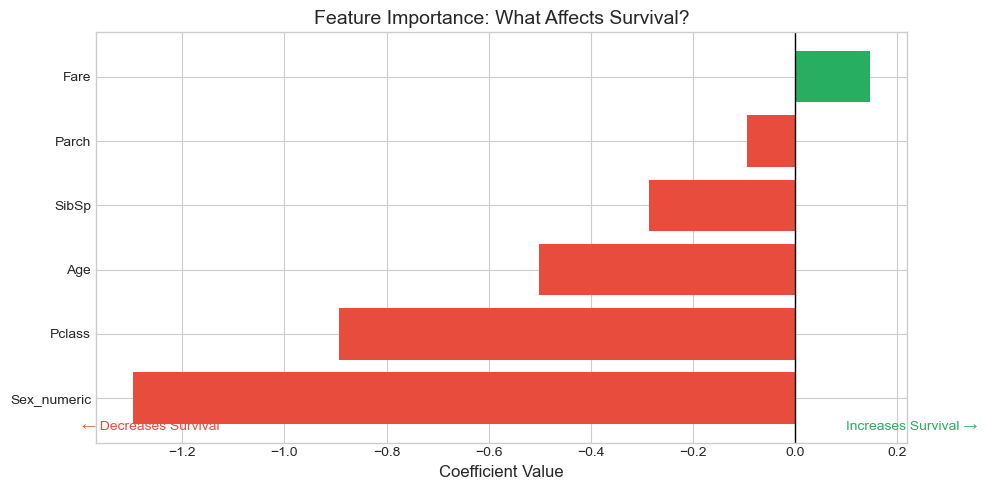

Key findings:
- Sex_numeric has the largest NEGATIVE coefficient → being male strongly decreases survival
- Pclass has a negative coefficient → higher class number (3rd) means lower survival
- Fare has a positive coefficient → paying more (1st class) increases survival

This matches history: 'Women and children first' and 1st class passengers had priority!


In [30]:
# Visualize the coefficients
plt.figure(figsize=(10, 5))

colors = ['#E74C3C' if c < 0 else '#27AE60' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Importance: What Affects Survival?', fontsize=14)

# Add labels
plt.text(coefficients['Coefficient'].min() - 0.1, -0.5, '← Decreases Survival', fontsize=10, color='#E74C3C')
plt.text(0.1, -0.5, 'Increases Survival →', fontsize=10, color='#27AE60')

plt.tight_layout()
plt.show()

print("Key findings:")
print("- Sex_numeric has the largest NEGATIVE coefficient → being male strongly decreases survival")
print("- Pclass has a negative coefficient → higher class number (3rd) means lower survival")
print("- Fare has a positive coefficient → paying more (1st class) increases survival")
print("\nThis matches history: 'Women and children first' and 1st class passengers had priority!")

---
# Part 4: Evaluation Metrics for Classification
## More Than Just Accuracy!

In regression, we used R² and RMSE. Classification has its own metrics:

| Metric | What It Measures | When to Use |
|--------|------------------|-------------|
| **Accuracy** | % of predictions that are correct | Balanced classes |
| **Precision** | When we predict positive, how often are we right? | Cost of false positives is high |
| **Recall** | Of all actual positives, how many did we catch? | Cost of false negatives is high |
| **F1-Score** | Balance of precision and recall | Imbalanced classes |

### Accuracy: The Simplest Metric

Accuracy = (Correct Predictions) / (Total Predictions)

In [31]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("ACCURACY")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"\nOut of {len(y_test)} test passengers:")
print(f"  Correct predictions: {(y_test == y_pred).sum()}")
print(f"  Wrong predictions: {(y_test != y_pred).sum()}")
print("="*50)

ACCURACY
Accuracy: 0.8045 (80.4%)

Out of 179 test passengers:
  Correct predictions: 144
  Wrong predictions: 35


### The Confusion Matrix: Seeing ALL the Details

Accuracy is a single number, but it hides important information. The confusion matrix shows us exactly WHERE the model makes mistakes.

> **Analogy:** Accuracy is like your GPA - a single number that summarizes performance. The confusion matrix is like your full transcript - it shows exactly what you got right and wrong.

In [32]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("\nHow to read this (for binary classification):")
print("")
print("                    Predicted")
print("                  Died    Survived")
print(f"Actual Died      [{cm[0,0]:3d}]     [{cm[0,1]:3d}]")
print(f"Actual Survived  [{cm[1,0]:3d}]     [{cm[1,1]:3d}]")
print("")
print("Diagonal (green) = Correct predictions")
print("Off-diagonal (red) = Mistakes")

Confusion Matrix:
[[95 15]
 [20 49]]

How to read this (for binary classification):

                    Predicted
                  Died    Survived
Actual Died      [ 95]     [ 15]
Actual Survived  [ 20]     [ 49]

Diagonal (green) = Correct predictions
Off-diagonal (red) = Mistakes


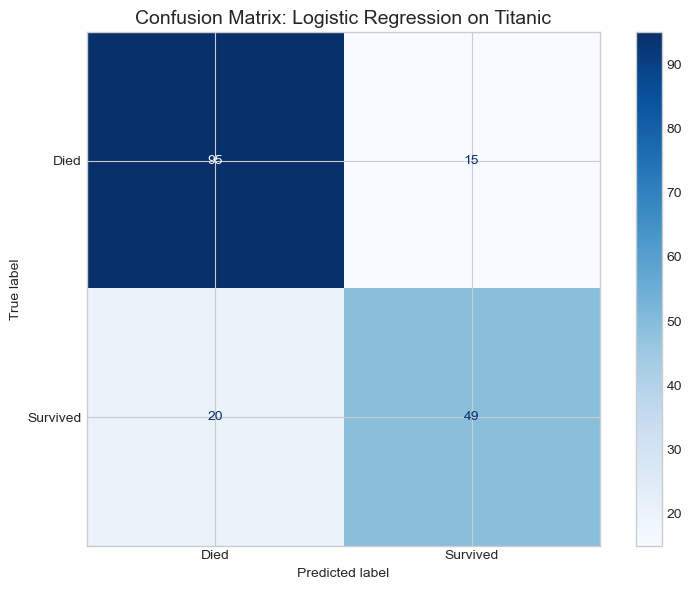


Breaking down the confusion matrix:
True Negatives (TN):   95 - Correctly predicted DIED
False Positives (FP):  15 - Predicted survived, but actually DIED
False Negatives (FN):  20 - Predicted died, but actually SURVIVED
True Positives (TP):   49 - Correctly predicted SURVIVED


In [38]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues', ax=plt.gca())

plt.title('Confusion Matrix: Logistic Regression on Titanic', fontsize=14)
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()

print("\nBreaking down the confusion matrix:")
print("="*60)
print(f"True Negatives (TN):  {tn:3d} - Correctly predicted DIED")
print(f"False Positives (FP): {fp:3d} - Predicted survived, but actually DIED")
print(f"False Negatives (FN): {fn:3d} - Predicted died, but actually SURVIVED")
print(f"True Positives (TP):  {tp:3d} - Correctly predicted SURVIVED")
print("="*60)

### Precision, Recall, and F1-Score

These metrics go beyond accuracy to tell us different aspects of model performance:

**Precision:** "When I predict survival, how often am I right?"
```
Precision = TP / (TP + FP)
```

**Recall:** "Of all the people who actually survived, how many did I catch?"
```
Recall = TP / (TP + FN)
```

**F1-Score:** The harmonic mean of precision and recall
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

> **When to use which?**
> - **High precision needed:** Spam filtering (don't want to lose important emails)
> - **High recall needed:** Disease screening (don't want to miss sick patients)
> - **F1-Score:** When you need balance, or with imbalanced datasets

In [39]:
# Calculate precision, recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*60)
print("CLASSIFICATION METRICS (for 'Survived' class)")
print("="*60)
print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"  → When we predict 'survived', we're right {precision*100:.1f}% of the time")
print(f"\nRecall: {recall:.4f} ({recall*100:.1f}%)")
print(f"  → We catch {recall*100:.1f}% of the actual survivors")
print(f"\nF1-Score: {f1:.4f}")
print(f"  → Harmonic mean of precision and recall")
print("="*60)

CLASSIFICATION METRICS (for 'Survived' class)
Precision: 0.7656 (76.6%)
  → When we predict 'survived', we're right 76.6% of the time

Recall: 0.7101 (71.0%)
  → We catch 71.0% of the actual survivors

F1-Score: 0.7368
  → Harmonic mean of precision and recall


In [40]:
# Get the full classification report
print("FULL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))
print("="*60)
print("\nWhat each column means:")
print("- precision: When we predict this class, how often are we right?")
print("- recall: Of all samples that ARE this class, how many did we catch?")
print("- f1-score: Harmonic mean of precision and recall")
print("- support: Number of actual samples in this class")

FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


What each column means:
- precision: When we predict this class, how often are we right?
- recall: Of all samples that ARE this class, how many did we catch?
- f1-score: Harmonic mean of precision and recall
- support: Number of actual samples in this class


### Why Accuracy Can Be Misleading

Imagine a disease that affects 1% of the population. A model that ALWAYS predicts "not sick" would be 99% accurate - but completely useless!

This is why precision, recall, and F1-score matter, especially with imbalanced data.

In [41]:
# Demonstration with a fake imbalanced scenario
print("Why Accuracy Can Be Misleading - A Fraud Detection Example")
print("="*60)
print("\nImagine 10,000 credit card transactions:")
print("  - 9,900 legitimate (99%)")
print("  - 100 fraudulent (1%)")
print("\nA 'lazy' model that always predicts 'legitimate':")
print(f"  - Accuracy: 99.0% (looks great!)")
print(f"  - Precision for fraud: undefined (never predicts fraud)")
print(f"  - Recall for fraud: 0% (catches ZERO fraud cases)")
print(f"  - F1-Score for fraud: 0")
print("\nThis 99% accurate model is USELESS for catching fraud!")
print("="*60)
print("\nLesson: Always look beyond accuracy, especially with imbalanced data!")

Why Accuracy Can Be Misleading - A Fraud Detection Example

Imagine 10,000 credit card transactions:
  - 9,900 legitimate (99%)
  - 100 fraudulent (1%)

A 'lazy' model that always predicts 'legitimate':
  - Accuracy: 99.0% (looks great!)
  - Precision for fraud: undefined (never predicts fraud)
  - Recall for fraud: 0% (catches ZERO fraud cases)
  - F1-Score for fraud: 0

This 99% accurate model is USELESS for catching fraud!

Lesson: Always look beyond accuracy, especially with imbalanced data!


---
# Part 5: Decision Trees for Classification
## A Different Approach

Remember decision trees from regression? They work almost identically for classification!

**Key difference:**
- **Regression trees:** Leaf nodes contain the AVERAGE of target values
- **Classification trees:** Leaf nodes contain the MOST COMMON CLASS (mode)

> **Analogy:** It's like playing 20 questions:
> - "Is the passenger female?" → Yes → "Probably survived!"
> - "Is the passenger female?" → No → "Is Pclass = 1?" → Yes → "Maybe survived"

Decision trees are popular because they're **interpretable** - you can see exactly WHY the model made each prediction.

In [42]:
# Train a decision tree classifier
# Note: Decision trees don't need scaled data!

tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)  # Using UNSCALED data

print("Decision Tree Classifier trained!")
print(f"Tree depth: {tree_clf.get_depth()}")
print(f"Number of leaves: {tree_clf.get_n_leaves()}")

Decision Tree Classifier trained!
Tree depth: 3
Number of leaves: 8


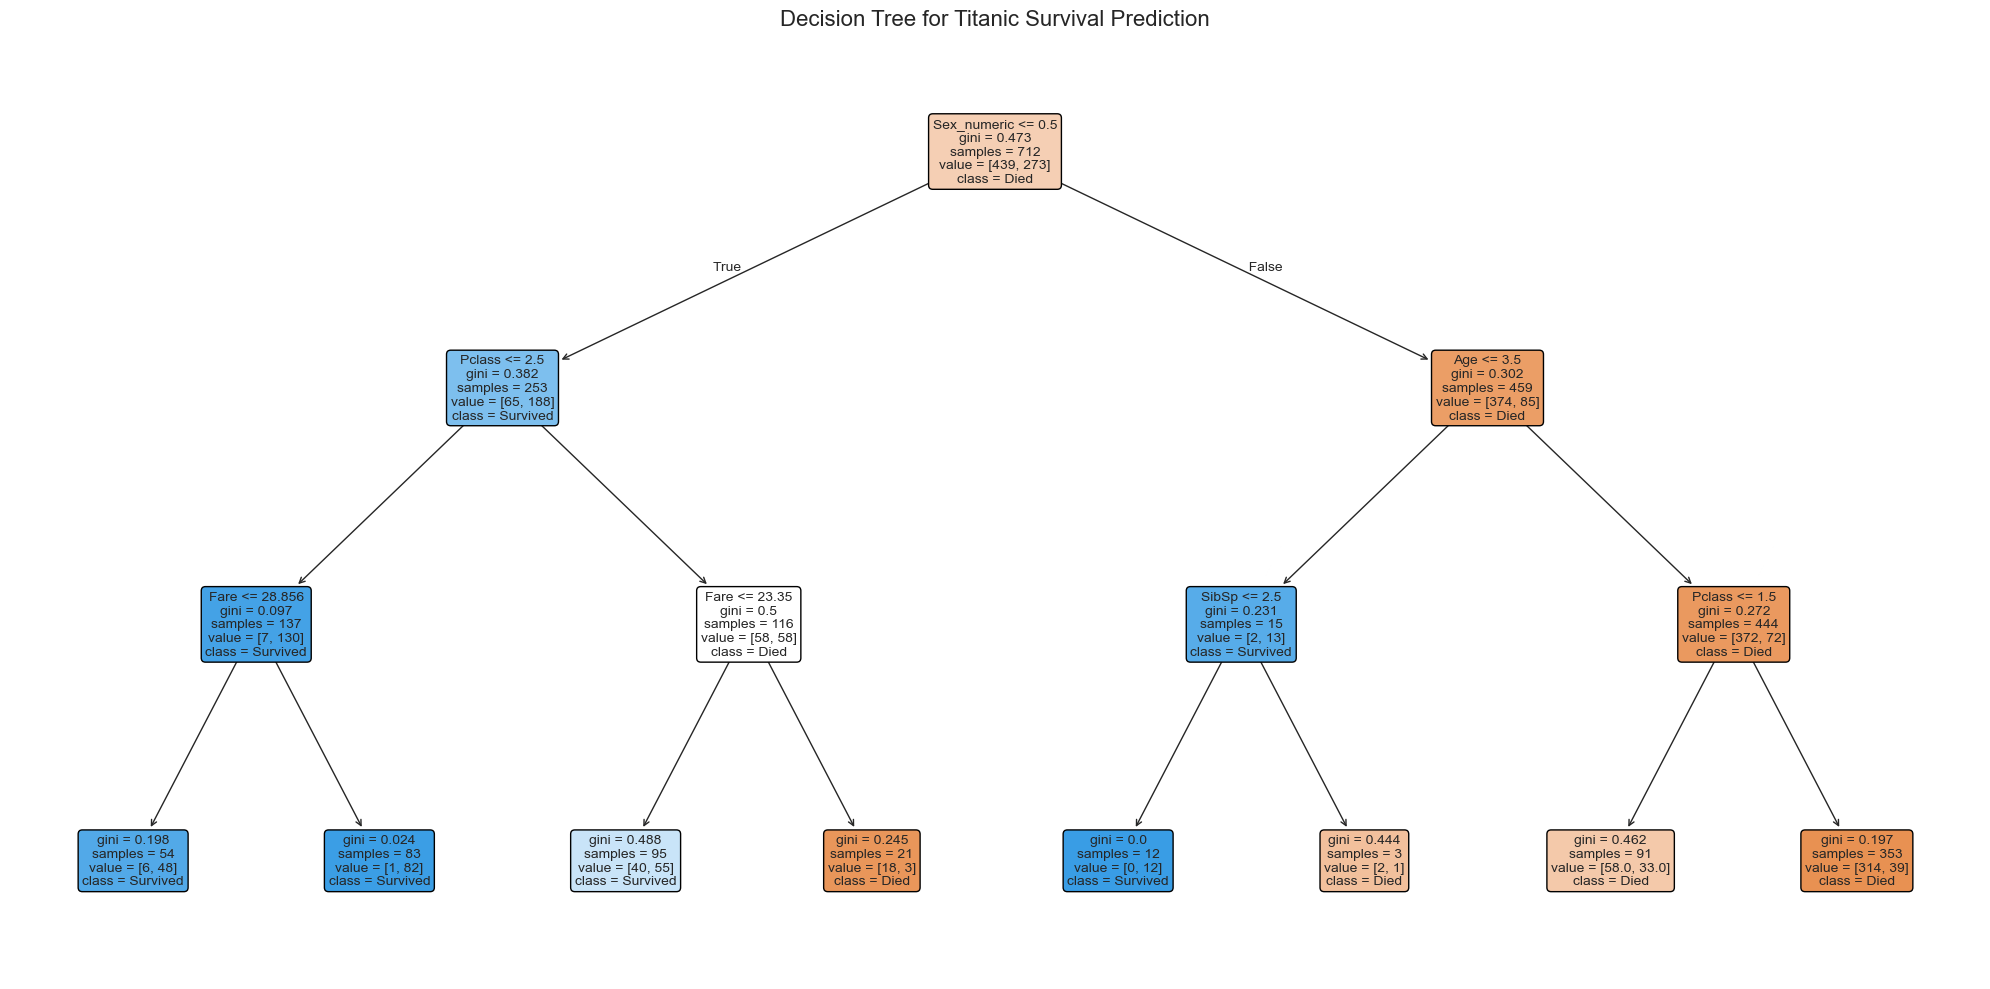

How to read this tree:
- Start at the top (root node)
- If the condition is TRUE, go LEFT
- If the condition is FALSE, go RIGHT
- The 'class' at each leaf is the predicted outcome

Notice:
- First split is on Sex_numeric - the most important feature!
- Sex_numeric <= 0.5 means 'female' (coded as 0)
- The tree learned: 'Women and children first'!


In [43]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))

plot_tree(tree_clf,
          feature_names=features,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree for Titanic Survival Prediction', fontsize=16)
plt.tight_layout()
plt.show()

print("How to read this tree:")
print("- Start at the top (root node)")
print("- If the condition is TRUE, go LEFT")
print("- If the condition is FALSE, go RIGHT")
print("- The 'class' at each leaf is the predicted outcome")
print("\nNotice:")
print("- First split is on Sex_numeric - the most important feature!")
print("- Sex_numeric <= 0.5 means 'female' (coded as 0)")
print("- The tree learned: 'Women and children first'!")

In [44]:
# Let's trace through a prediction manually
print("="*60)
print("Let's trace a prediction through the tree!")
print("="*60)

sample_idx = 0
sample = X_test.iloc[sample_idx]
print(f"\nPassenger details:")
print(f"  Pclass: {sample['Pclass']} ({'1st' if sample['Pclass']==1 else '2nd' if sample['Pclass']==2 else '3rd'} class)")
print(f"  Sex: {'Male' if sample['Sex_numeric']==1 else 'Female'}")
print(f"  Age: {sample['Age']:.1f}")
print(f"  Fare: ${sample['Fare']:.2f}")

print(f"\nActual outcome: {'Survived' if y_test.iloc[sample_idx] == 1 else 'Died'}")

# Make prediction
prediction = tree_clf.predict([sample.values])[0]
print(f"Tree's prediction: {'Survived' if prediction == 1 else 'Died'}")

print("\nFollow along in the tree diagram to see how it made this decision!")

Let's trace a prediction through the tree!

Passenger details:
  Pclass: 3.0 (3rd class)
  Sex: Male
  Age: 24.0
  Fare: $24.15

Actual outcome: Died
Tree's prediction: Died

Follow along in the tree diagram to see how it made this decision!


In [45]:
# Evaluate the decision tree
y_pred_tree = tree_clf.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("="*60)
print("DECISION TREE RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_tree:.4f} ({accuracy_tree*100:.1f}%)")
print(f"\nConfusion Matrix:")
print(cm_tree)
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, target_names=['Died', 'Survived']))

DECISION TREE RESULTS
Accuracy: 0.8101 (81.0%)

Confusion Matrix:
[[100  10]
 [ 24  45]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.81      0.91      0.85       110
    Survived       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



### Compare: Logistic Regression vs Decision Tree

In [46]:
# Side-by-side comparison
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Metric':<25} {'Logistic Reg':<15} {'Decision Tree':<15}")
print("-"*60)
print(f"{'Accuracy':<25} {accuracy:<15.4f} {accuracy_tree:<15.4f}")

# Calculate F1 for both
f1_log_reg = f1_score(y_test, y_pred)
f1_tree = f1_score(y_test, y_pred_tree)
print(f"{'F1-Score (Survived)':<25} {f1_log_reg:<15.4f} {f1_tree:<15.4f}")

precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
print(f"{'Precision (Survived)':<25} {precision:<15.4f} {precision_tree:<15.4f}")
print(f"{'Recall (Survived)':<25} {recall:<15.4f} {recall_tree:<15.4f}")
print("="*60)

print("\nKey Differences:")
print("- Logistic Regression: Needs scaled data, outputs probabilities, linear decision boundary")
print("- Decision Tree: No scaling needed, interpretable rules, can capture non-linear patterns")

MODEL COMPARISON
Metric                    Logistic Reg    Decision Tree  
------------------------------------------------------------
Accuracy                  0.8045          0.8101         
F1-Score (Survived)       0.7368          0.7258         
Precision (Survived)      0.7656          0.8182         
Recall (Survived)         0.7101          0.6522         

Key Differences:
- Logistic Regression: Needs scaled data, outputs probabilities, linear decision boundary
- Decision Tree: No scaling needed, interpretable rules, can capture non-linear patterns


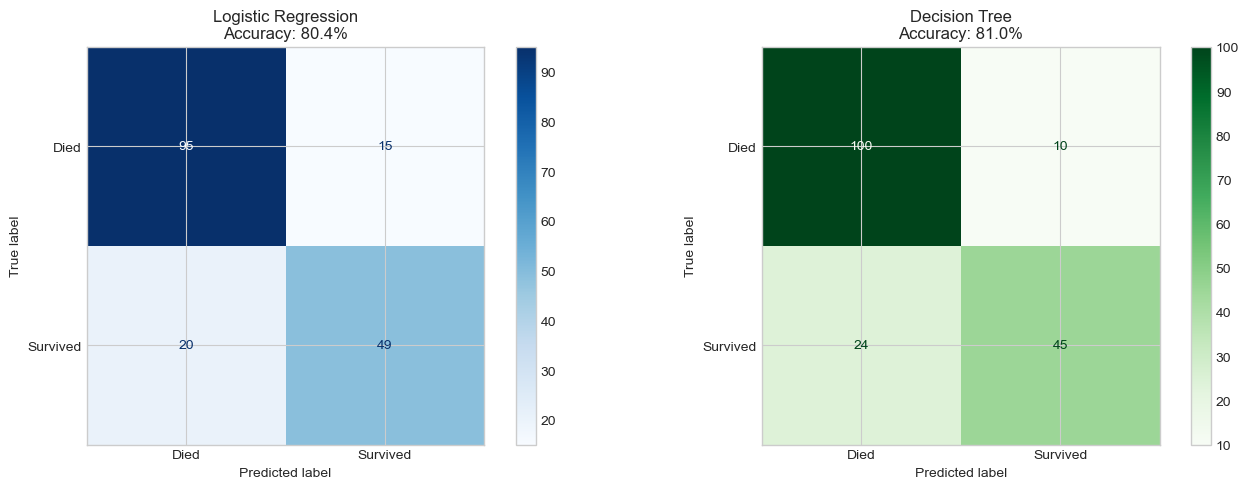

In [47]:
# Visualize both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy:.1%}', fontsize=12)

# Decision Tree
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Died', 'Survived']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Decision Tree\nAccuracy: {accuracy_tree:.1%}', fontsize=12)

plt.tight_layout()
plt.show()

### Feature Importance from Decision Trees

Decision trees automatically tell us which features are most important for making predictions!

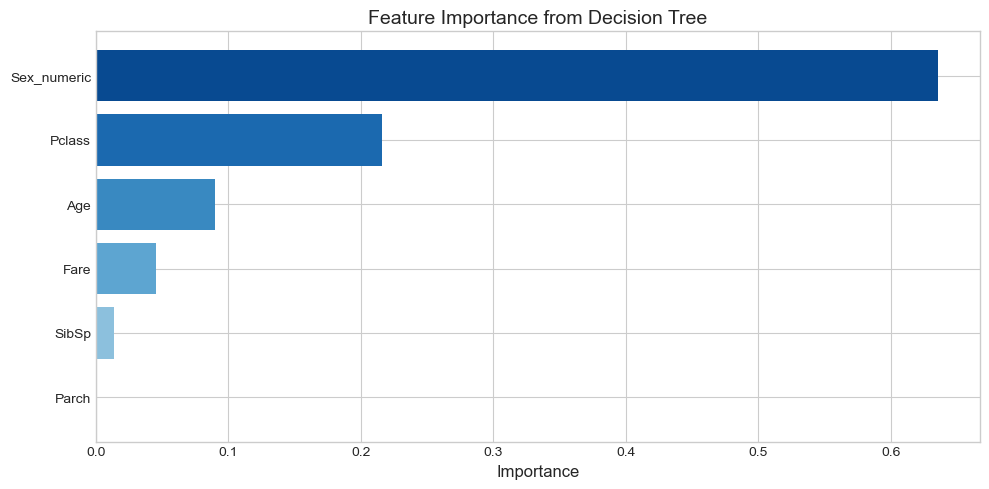

Feature Importances:
  Sex_numeric    : 0.6355
  Pclass         : 0.2160
  Age            : 0.0902
  Fare           : 0.0450
  SibSp          : 0.0134
  Parch          : 0.0000

Sex is by far the most important feature - 'Women and children first'!


In [48]:
# Get feature importances
importances = tree_clf.feature_importances_

# Create a bar chart
plt.figure(figsize=(10, 5))
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(features)))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance from Decision Tree', fontsize=14)
plt.tight_layout()
plt.show()

print("Feature Importances:")
for _, row in feature_importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<15}: {row['Importance']:.4f}")

print("\nSex is by far the most important feature - 'Women and children first'!")

---
# Part 6: Summary & Key Takeaways

## What We Learned Today

### 1. Classification vs Regression
- **Classification:** Predict categories (survived/died, spam/not spam)
- **Regression:** Predict continuous numbers (price, temperature)

### 2. Logistic Regression
- Despite the name, it's for CLASSIFICATION
- Uses the sigmoid function to output probabilities
- Needs scaled features
- Coefficients are interpretable

### 3. Evaluation Metrics
- **Accuracy:** Overall % correct (but can be misleading!)
- **Confusion Matrix:** Shows all types of errors (TP, TN, FP, FN)
- **Precision:** When we predict positive, are we right?
- **Recall:** Do we catch all the positives?
- **F1-Score:** Balance of precision and recall

### 4. Decision Trees for Classification
- Same structure as regression trees
- Leaf nodes predict the most common class (not average)
- Highly interpretable - you can see the rules!
- No scaling needed

### Coming Up Next!
- More classification algorithms (KNN, SVM, Naive Bayes)
- Ensemble methods (Random Forest, Gradient Boosting)

---
## Quick Reference: Classification Code Patterns

```python
# Basic pattern for any classifier
from sklearn.classifier_module import ClassifierName

model = ClassifierName(hyperparameters)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)  # If supported

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
print(classification_report(y_test, predictions))

# Logistic Regression (needs scaling)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Decision Tree (no scaling needed)
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)
plot_tree(tree, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
```

In [49]:
print("\n" + "="*60)
print("Congratulations! You've completed the Classification")
print("walkthrough. You now understand the fundamentals of")
print("classification algorithms and evaluation metrics!")
print("="*60)


Congratulations! You've completed the Classification
walkthrough. You now understand the fundamentals of
classification algorithms and evaluation metrics!
